In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
Data = 'data/T1.csv'
df = pd.read_csv(Data, sep=',')

In [3]:
df.sample(10)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
16073,27 04 2018 05:20,480.239899,6.090627,654.988593,58.012081
17046,03 05 2018 23:30,0.000000,2.171774,0.000000,112.620697
28713,24 07 2018 15:00,0.000000,2.280903,0.000000,227.609604
5832,14 02 2018 23:50,1833.311035,8.635923,1912.450559,206.931396
31539,13 08 2018 06:30,2401.652100,9.963110,2768.950675,63.054520
4779,07 02 2018 16:20,1952.866943,9.123545,2223.920615,181.305206
13439,08 04 2018 20:00,2776.138916,11.232990,3348.647204,59.119049
36407,16 09 2018 10:40,176.932602,4.352429,191.400074,30.408070
34113,31 08 2018 09:30,1665.150024,8.597458,1888.424121,62.449959
1344,10 01 2018 11:30,0.000000,2.623512,0.000000,59.864738


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  str    
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), str(1)
memory usage: 1.9 MB


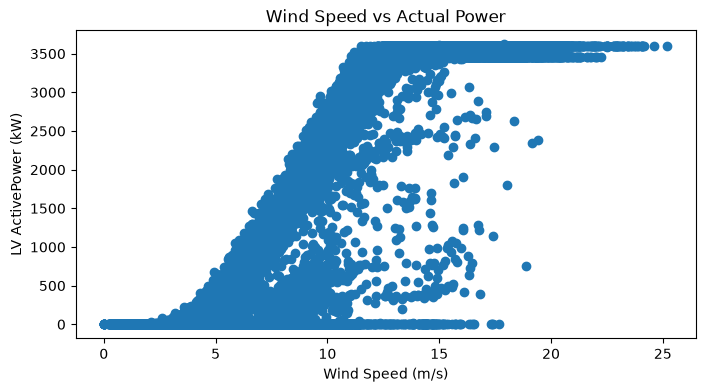

In [10]:
fig, ax = plt.subplots(figsize = (8, 4))

ax.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'])
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('LV ActivePower (kW)')
ax.set_title('Wind Speed vs Actual Power')

plt.show()

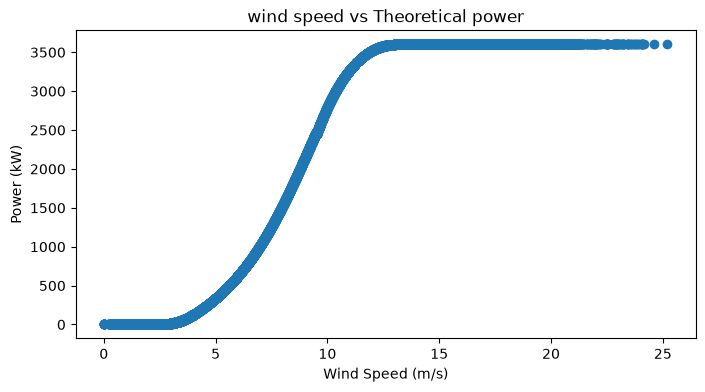

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(df['Wind Speed (m/s)'], df['Theoretical_Power_Curve (KWh)'])
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
ax.set_title('wind speed vs Theoretical power')

plt.show()

/tmp/ipykernel_6837/1553716753.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


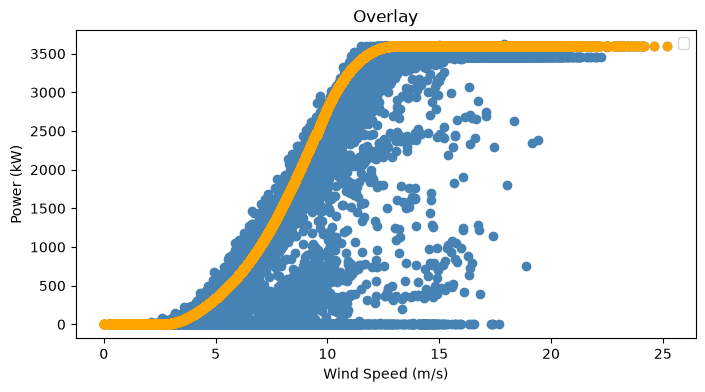

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], color='steelblue')
ax.scatter(df['Wind Speed (m/s)'], df['Theoretical_Power_Curve (KWh)'], color='orange')
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
ax.set_title('Overlay')
ax.legend()

plt.show()

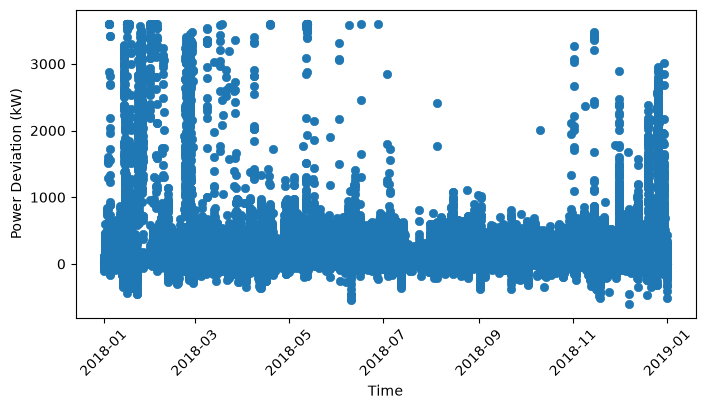

In [25]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='mixed') 
df['Residual'] = df['Theoretical_Power_Curve (KWh)'] - df['LV ActivePower (kW)']

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Date/Time'], df['Residual'], linewidth=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Power Deviation (kW)')
plt.xticks(rotation=45)

plt.show()

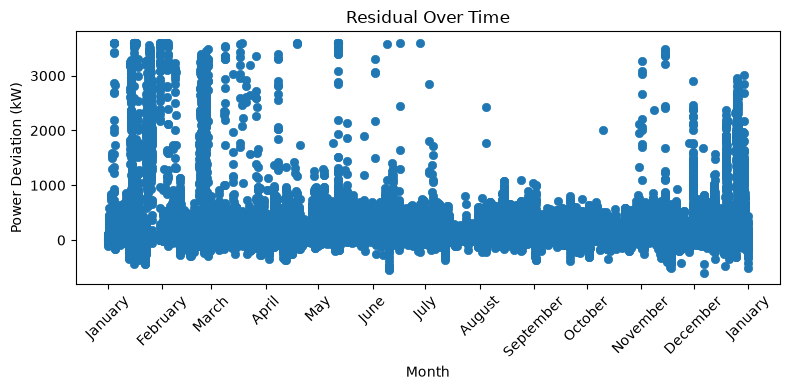

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Date/Time'], df['Residual'], linewidth=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))

ax.set_xlabel('Month')
ax.set_ylabel('Power Deviation (kW)')
ax.set_title('Residual Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Residual Analysis: Power Deviation Over Time

The residual (`Theoretical Power − Actual Power`) was plotted across the full year to
identify when the turbine's actual output diverges most from its expected output.

**Observations:**

- Residuals are not uniformly distributed across the year — deviation is noticeably
  higher and more frequent during **January–February, May, and November–December**,
  with tighter, lower residuals through **June–September**.
- Peak residual values (up to ~3,600 kW) occur most densely in the winter months,
  suggesting a possible seasonal driver such as icing on blades, reduced air density
  effects, or seasonal maintenance/curtailment scheduling.
- The summer months show a calmer, more consistent residual band (mostly under
  ~500 kW), consistent with stable, healthy operation.
- This clustering pattern indicates the anomalies are **not randomly distributed
  noise** — they carry a time-dependent structure, which points toward an underlying
  operational or environmental cause rather than isolated sensor error.


In [31]:
df['wind_bin'] = (df['Wind Speed (m/s)'] // 0.5) * 0.5
bin_median = df.groupby('wind_bin')['LV ActivePower (kW)'].transform('median')
df['flag_anomaly'] = (bin_median - df['LV ActivePower (kW)']) > 500

clean_data = df[~df['flag_anomaly']]

/tmp/ipykernel_6837/2899864725.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


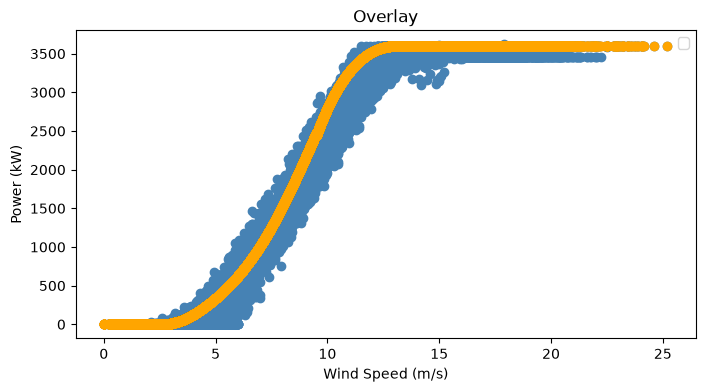

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(clean_data['Wind Speed (m/s)'], clean_data['LV ActivePower (kW)'], color='steelblue')
ax.scatter(clean_data['Wind Speed (m/s)'], clean_data['Theoretical_Power_Curve (KWh)'], color='orange')
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
ax.set_title('Overlay')
ax.legend()

plt.show()

In [34]:
clean_data.to_csv('data/wind_turbine_clean.csv', index=False)